[INFO] Simulating database data extraction...

--- Raw Unfiltered Head DataFrame Snapshot ---
            timestamp      device_id  temperature  humidity  pressure_hpa  \
0 2026-06-21 12:00:00  arduino_dht22        23.15     46.76           NaN   
1 2026-06-21 12:00:05   esp32_bmp280        24.26       NaN       1012.63   
2 2026-06-21 12:00:10  arduino_dht22        22.96     46.19           NaN   
3 2026-06-21 12:00:15   esp32_bmp280        24.36       NaN       1012.67   
4 2026-06-21 12:00:20  arduino_dht22        23.19     45.96           NaN   
5 2026-06-21 12:00:25   esp32_bmp280        24.37       NaN       1012.16   

  status  
0     OK  
1     OK  
2     OK  
3     OK  
4     OK  
5     OK  

[PROCESS] Filtering out separate hardware node metrics groups...

[METRIC] Arduino DHT22 Mean Temperature: 22.93°C
[METRIC] ESP32 BMP280 Max Pressure Value: 1013.86 hPa

[VISUALIZE] Launching plotting viewport...


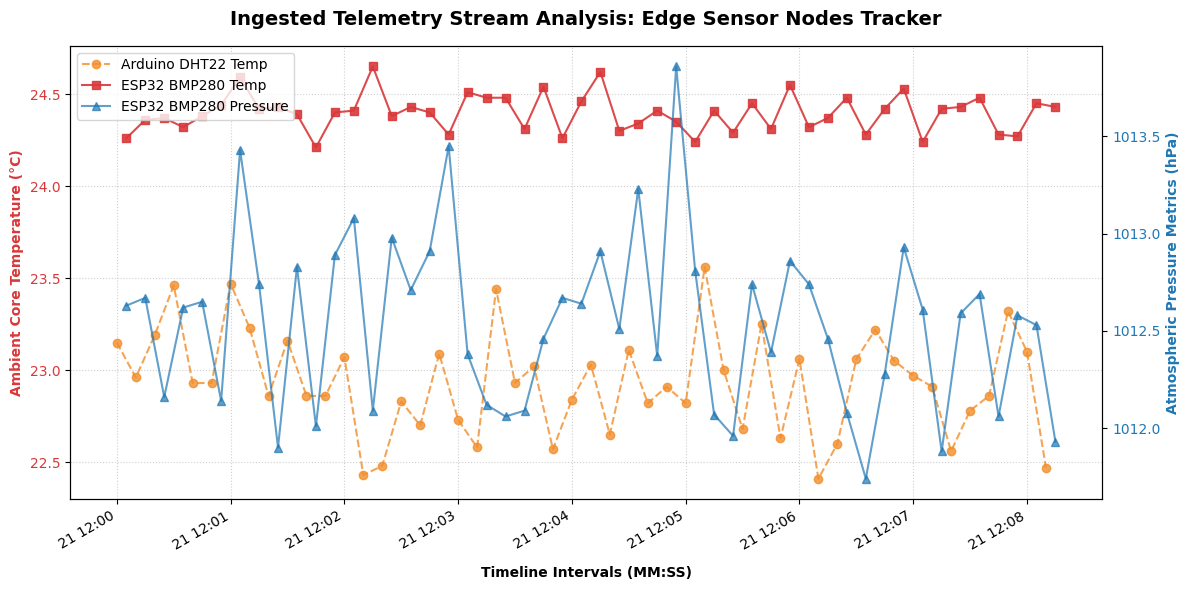

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==============================================================================
# 1. DATA GENERATION (Simulating Database Extraction via NumPy)
# ==============================================================================
print("[INFO] Simulating database data extraction...")
np.random.seed(42)  # Seeds random numbers for consistent results across runs
sample_size = 100

# Build a linear progression of mock database timestamps
base_time = datetime(2026, 6, 21, 12, 0, 0)
time_vector = [base_time + timedelta(seconds=i*5) for i in range(sample_size)]

# Generate device telemetry readings using localized random normal distributions
arduino_temp = np.random.normal(loc=23.0, scale=0.3, size=sample_size//2)
arduino_humid = np.random.normal(loc=46.5, scale=0.8, size=sample_size//2)

esp32_temp = np.random.normal(loc=24.4, scale=0.1, size=sample_size//2)
esp32_press = np.random.normal(loc=1012.5, scale=0.5, size=sample_size//2)

# ==============================================================================
# 2. DATA FRAME CONSTRUCTION & WRAPPING (Pandas Pipeline)
# ==============================================================================
# Interleave data vectors to simulate real-world arrival order over the network
records = []
for i in range(sample_size // 2):
    # Append simulated row from the Arduino DHT22
    records.append({
        "timestamp": time_vector[2 * i],
        "device_id": "arduino_dht22",
        "temperature": round(arduino_temp[i], 2),
        "humidity": round(arduino_humid[i], 2),
        "pressure_hpa": None,
        "status": "OK"
    })
    # Append simulated row from the ESP32 BMP280
    records.append({
        "timestamp": time_vector[2 * i + 1],
        "device_id": "esp32_bmp280",
        "temperature": round(esp32_temp[i], 2),
        "humidity": None,
        "pressure_hpa": round(esp32_press[i], 2),
        "status": "OK" if esp32_press[i] > 1012.0 else "UNSTABLE"
    })

# Convert raw records list to a structured Pandas DataFrame
df = pd.DataFrame(records)

print("\n--- Raw Unfiltered Head DataFrame Snapshot ---")
print(df.head(6))

# Execute Data Sub-Setting and Row Filtering Operations
print("\n[PROCESS] Filtering out separate hardware node metrics groups...")
arduino_df = df[df['device_id'] == 'arduino_dht22'].dropna(axis=1, how='all')
esp32_df = df[df['device_id'] == 'esp32_bmp280'].dropna(axis=1, how='all')

# Calculate high-level aggregates using native Pandas math operators
print(f"\n[METRIC] Arduino DHT22 Mean Temperature: {arduino_df['temperature'].mean():.2f}°C")
print(f"[METRIC] ESP32 BMP280 Max Pressure Value: {esp32_df['pressure_hpa'].max():.2f} hPa")

# ==============================================================================
# 3. GRAPHICAL RENDERING (Matplotlib Engine)
# ==============================================================================
print("\n[VISUALIZE] Launching plotting viewport...")

# Instantiate a multi-axis chart structure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Layer A: Primary Y-Axis (Temperature Trends)
color_temp = '#d9383a'
ax1.set_xlabel('Timeline Intervals (MM:SS)', fontweight='bold', labelpad=10)
ax1.set_ylabel('Ambient Core Temperature (°C)', color=color_temp, fontweight='bold')

# Plot line metrics for both hardware configurations
ax1.plot(arduino_df['timestamp'], arduino_df['temperature'], color='#f28e2b',
         linestyle='--', marker='o', alpha=0.8, label='Arduino DHT22 Temp')
ax1.plot(esp32_df['timestamp'], esp32_df['temperature'], color=color_temp,
         linestyle='-', marker='s', alpha=0.9, label='ESP32 BMP280 Temp')
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot Layer B: Secondary Y-Axis sharing the exact same X-Axis footprint
ax2 = ax1.twinx()
color_press = '#1f77b4'
ax2.set_ylabel('Atmospheric Pressure Metrics (hPa)', color=color_press, fontweight='bold')

# Plot barometric line metrics
ax2.plot(esp32_df['timestamp'], esp32_df['pressure_hpa'], color=color_press,
         linestyle='-', marker='^', alpha=0.7, label='ESP32 BMP280 Pressure')
ax2.tick_params(axis='y', labelcolor=color_press)

# Layout adjustments and clean date labels formatting
fig.autofmt_xdate()
plt.title('Ingested Telemetry Stream Analysis: Edge Sensor Nodes Tracker',
          fontsize=14, fontweight='bold', pad=15)

# Gather and overlay composite legend panels from both coordinate engines
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()